# 01 — Distributions in Quantitative Finance

**Book reference:** *Quantitative Trading* — Ernest Chan, Ch. 1–2 background  
**Goal:** Understand how asset returns are actually distributed, why the normal distribution assumption is dangerous, and how to measure and visualize these properties in Python.

---

## Why This Matters

Most introductory statistics courses teach the normal (Gaussian) distribution as the default model for everything. In finance, blindly applying it kills funds.

The 2008 financial crisis was partly caused by risk models (VaR) that assumed returns were normally distributed — a model that said a 25-standard-deviation move was essentially impossible. It happened. Twice. In one week.

You need to understand:
1. What a normal distribution actually implies about returns
2. What real return distributions look like (spoiler: fat tails)
3. How to measure the difference quantitatively

In [1]:
# Install dependencies if needed
# !pip install yfinance scipy statsmodels seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

---

## 1. Simple Returns vs. Log Returns

Before looking at distributions, we need to establish *what we're distributing*.

**Simple return:** $R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$

**Log return:** $r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$

**Why quants use log returns:**
- They're additive over time: $r_{t_1 \to t_3} = r_{t_1 \to t_2} + r_{t_2 \to t_3}$ (simple returns are not)
- They're symmetric: a +100% followed by a -50% = 0 in log returns, not -50% simple
- They're approximately normal (though still fat-tailed in practice)
- Most statistical models assume additivity — log returns satisfy this

For small returns (< ~5%), simple ≈ log. At larger magnitudes they diverge.

In [4]:
# Download ~10 years of SPY (S&P 500 ETF) daily prices
spy = yf.download('SPY', start='2015-01-01', end='2025-01-01', auto_adjust=True)
prices = spy['Close'].squeeze().dropna()

simple_returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"Observations: {len(log_returns)}")
print(f"Date range: {log_returns.index[0].date()} to {log_returns.index[-1].date()}")

# Show they're nearly identical for small moves
comparison = pd.DataFrame({'simple': simple_returns, 'log': log_returns})
comparison['difference'] = comparison['simple'] - comparison['log']
print(f"\nMean abs difference (simple vs log): {comparison['difference'].abs().mean():.6f}")
print("(Negligible for daily returns — they diverge more for weekly/monthly)")

[*********************100%***********************]  1 of 1 completed

Observations: 2515
Date range: 2015-01-05 to 2024-12-31

Mean abs difference (simple vs log): 0.000062
(Negligible for daily returns — they diverge more for weekly/monthly)


---

## 2. The Normal Distribution

The normal distribution $\mathcal{N}(\mu, \sigma^2)$ is fully described by two parameters:
- **Mean** $\mu$: the center (expected return)
- **Std dev** $\sigma$: the spread (volatility — the most important risk measure in finance)

Under a normal model, the probability of a move larger than $k$ standard deviations falls off *extremely* fast (exponentially). The key rule of thumb:

| Move Size | Probability | Expected frequency (daily) |
|---|---|---|
| > 1σ | 31.7% | ~80 days/year |
| > 2σ | 4.6% | ~12 days/year |
| > 3σ | 0.27% | ~0.7 days/year |
| > 4σ | 0.0063% | ~1 day per 63 years |
| > 5σ | 0.000057% | ~1 day per 7,000 years |

If those "once per 7,000 years" moves happen every few years in real markets, the model is wrong.

In [5]:
mu = log_returns.mean()
sigma = log_returns.std()

print(f"SPY daily log returns (2015-2025):")
print(f"  Mean (μ):    {mu:.6f}  ({mu*252:.2%} annualized)")
print(f"  Std dev (σ): {sigma:.6f}  ({sigma*np.sqrt(252):.2%} annualized)")

# How many standard deviations was the COVID crash (March 16, 2020)?
covid_crash_date = '2020-03-16'
if covid_crash_date in log_returns.index:
    covid_return = log_returns[covid_crash_date]
    z_score = (covid_return - mu) / sigma
    p_normal = stats.norm.cdf(z_score)  # probability of return this bad or worse
    print(f"\nCOVID crash ({covid_crash_date}):")
    print(f"  Return:  {covid_return:.4f} ({covid_return:.2%})")
    print(f"  Z-score: {z_score:.1f}σ")
    print(f"  Under normal model, P(return ≤ this): {p_normal:.2e}")
    print(f"  That's roughly 1 in {int(1/p_normal):,} days = {int(1/p_normal/252):,} trading years")

SPY daily log returns (2015-2025):
  Mean (μ):    0.000486  (12.25% annualized)
  Std dev (σ): 0.011137  (17.68% annualized)

COVID crash (2020-03-16):
  Return:  -0.1159 (-11.59%)
  Z-score: -10.4σ
  Under normal model, P(return ≤ this): 7.39e-26
  That's roughly 1 in 13,540,538,416,405,037,675,708,416 days = 53,732,295,303,194,596,081,664 trading years


---

## 3. Fat Tails — The Reality

Real return distributions have **fat tails** (also called heavy tails or leptokurtosis). This means:
- The center of the distribution is *more peaked* (more small moves) than normal
- The tails are *much fatter* (large moves happen far more often than normal predicts)

**Kurtosis** measures tail heaviness. For a normal distribution, kurtosis = 3 (or excess kurtosis = 0). Real equity returns typically have excess kurtosis of 5–20+, meaning catastrophic events are orders of magnitude more likely than Gaussian models predict.

**Skewness** measures asymmetry. Equity returns tend to be negatively skewed — crashes are larger and faster than rallies (equities "take the stairs up and the elevator down").

In [6]:
skewness = stats.skew(log_returns)
excess_kurtosis = stats.kurtosis(log_returns)  # scipy returns excess kurtosis (normal=0)

print(f"Distribution shape of SPY daily log returns:")
print(f"  Skewness:        {skewness:.3f}  (normal=0, negative=left tail heavier)")
print(f"  Excess kurtosis: {excess_kurtosis:.3f}  (normal=0, positive=fat tails)")

# Count actual large moves vs. what normal model predicts
n = len(log_returns)
z_scores = (log_returns - mu) / sigma

for threshold in [2, 3, 4, 5]:
    actual = (z_scores.abs() > threshold).sum()
    expected = n * 2 * (1 - stats.norm.cdf(threshold))  # two-tailed
    print(f"  |z| > {threshold}σ:  actual={actual:3d}, normal model predicts={expected:.1f}  (ratio={actual/expected:.1f}x)")

Distribution shape of SPY daily log returns:
  Skewness:        -0.800  (normal=0, negative=left tail heavier)
  Excess kurtosis: 13.634  (normal=0, positive=fat tails)
  |z| > 2σ:  actual=118, normal model predicts=114.4  (ratio=1.0x)
  |z| > 3σ:  actual= 36, normal model predicts=6.8  (ratio=5.3x)
  |z| > 4σ:  actual= 17, normal model predicts=0.2  (ratio=106.7x)
  |z| > 5σ:  actual=  8, normal model predicts=0.0  (ratio=5548.4x)


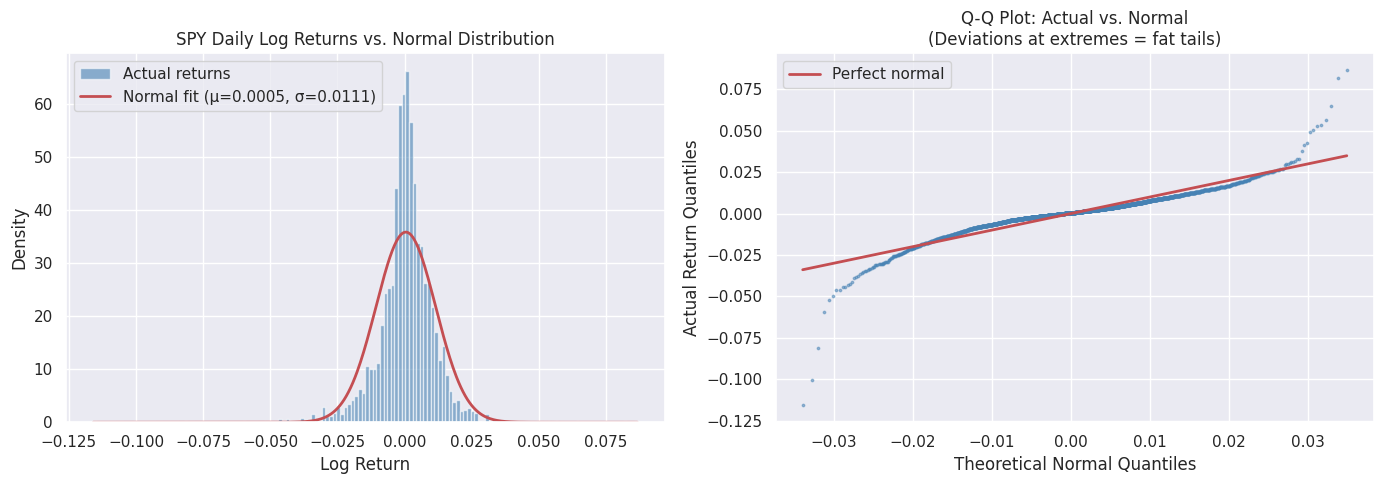

Q-Q plot interpretation:
  - Points on the red line → returns match normal
  - Left tail curves DOWN → actual crashes are larger than normal predicts
  - Right tail curves UP  → actual rallies are larger than normal predicts


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: histogram vs. normal fit ---
ax = axes[0]
x = np.linspace(log_returns.min(), log_returns.max(), 500)
normal_pdf = stats.norm.pdf(x, mu, sigma)

ax.hist(log_returns, bins=150, density=True, alpha=0.6, color='steelblue', label='Actual returns')
ax.plot(x, normal_pdf, 'r-', linewidth=2, label=f'Normal fit (μ={mu:.4f}, σ={sigma:.4f})')
ax.set_title('SPY Daily Log Returns vs. Normal Distribution')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()

# --- Right plot: Q-Q plot (fat tails show up as S-curve deviation) ---
ax2 = axes[1]
sorted_returns = np.sort(log_returns)
n_pts = len(sorted_returns)
theoretical_quantiles = stats.norm.ppf(np.linspace(0.001, 0.999, n_pts), mu, sigma)

ax2.scatter(theoretical_quantiles, sorted_returns, s=3, alpha=0.5, color='steelblue')
ax2.plot([theoretical_quantiles[0], theoretical_quantiles[-1]],
         [theoretical_quantiles[0], theoretical_quantiles[-1]],
         'r-', linewidth=2, label='Perfect normal')
ax2.set_title('Q-Q Plot: Actual vs. Normal\n(Deviations at extremes = fat tails)')
ax2.set_xlabel('Theoretical Normal Quantiles')
ax2.set_ylabel('Actual Return Quantiles')
ax2.legend()

plt.tight_layout()
plt.show()

print("Q-Q plot interpretation:")
print("  - Points on the red line → returns match normal")
print("  - Left tail curves DOWN → actual crashes are larger than normal predicts")
print("  - Right tail curves UP  → actual rallies are larger than normal predicts")

---

## 4. Better Distribution Models

Since returns aren't normal, what *is* a better model? Common choices:

| Distribution | Parameters | Use case |
|---|---|---|
| **Student's t** | df (degrees of freedom) | General fat-tailed returns; lower df = fatter tails |
| **Normal** | μ, σ | Baseline / analytically tractable |
| **Log-normal** | μ, σ of log | Price levels (not returns); prices can't go negative |
| **Stable / Lévy** | α, β, c, δ | Very fat tails; hard to work with analytically |

The **Student's t distribution** is the most practical improvement — it has an extra parameter (degrees of freedom, `df`) that controls tail thickness. As df → ∞, it converges to normal. For equity daily returns, df is typically around 3–6.

In [ ]:
# Fit a Student's t distribution to SPY returns
df_t, loc_t, scale_t = stats.t.fit(log_returns)

print(f"Student's t fit to SPY daily log returns:")
print(f"  Degrees of freedom (df): {df_t:.2f}  (lower = fatter tails)")
print(f"  Location (loc):          {loc_t:.6f}")
print(f"  Scale:                   {scale_t:.6f}")
print()
print(f"Interpretation of df={df_t:.1f}:")
if df_t < 3:
    print("  Variance is technically infinite — extreme tail events")
elif df_t < 5:
    print("  Very fat tails — large crashes ~10-100x more likely than normal")
else:
    print("  Moderately fat tails")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.linspace(log_returns.quantile(0.001), log_returns.quantile(0.999), 500)

normal_pdf = stats.norm.pdf(x, mu, sigma)
t_pdf = stats.t.pdf(x, df_t, loc_t, scale_t)

ax.hist(log_returns, bins=150, density=True, alpha=0.5, color='steelblue', label='Actual returns')
ax.plot(x, normal_pdf, 'r--', linewidth=2, label='Normal fit')
ax.plot(x, t_pdf, 'g-', linewidth=2, label=f"Student's t fit (df={df_t:.1f})")
ax.set_title("SPY Daily Returns: Normal vs. Student's t Fit")
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

---

## 5. The Log-Normal Distribution for Prices

While *returns* are roughly t-distributed, *price levels* follow a **log-normal distribution** (if you assume log returns are normal).

This is the foundation of the **Black-Scholes options model** and geometric Brownian motion. The key insight: if prices were normally distributed, they could go negative — which is impossible for most assets. Log-normal prices are always positive.

$P_t = P_0 \cdot e^{r_1 + r_2 + \ldots + r_t}$

where each $r_i$ is a log return. Since the exponent of a sum of roughly-normal values is log-normal, prices are approximately log-normal.

In [ ]:
# Simulate future price paths using log-normal model (Monte Carlo)
np.random.seed(42)

n_paths = 200
n_days = 252  # 1 trading year
S0 = float(prices.iloc[-1])  # current price

# Simulate log returns and compound them into price paths
daily_returns_sim = np.random.normal(mu, sigma, (n_days, n_paths))
price_paths = S0 * np.exp(np.cumsum(daily_returns_sim, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: simulated paths
ax = axes[0]
ax.plot(price_paths, alpha=0.1, color='steelblue', linewidth=0.8)
ax.axhline(S0, color='red', linestyle='--', linewidth=1.5, label=f'Starting price ${S0:.2f}')
ax.set_title(f'Log-Normal Monte Carlo: {n_paths} Simulated SPY Paths (1 Year)')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Price ($)')
ax.legend()

# Right: distribution of final prices
ax2 = axes[1]
final_prices = price_paths[-1, :]
ax2.hist(final_prices, bins=40, density=True, color='steelblue', alpha=0.7)
ax2.axvline(S0, color='red', linestyle='--', linewidth=1.5, label=f'Start: ${S0:.2f}')
ax2.axvline(np.median(final_prices), color='green', linestyle='-', linewidth=1.5,
            label=f'Median: ${np.median(final_prices):.2f}')
ax2.axvline(np.mean(final_prices), color='orange', linestyle='-', linewidth=1.5,
            label=f'Mean: ${np.mean(final_prices):.2f}')
ax2.set_title('Distribution of Final Prices After 1 Year')
ax2.set_xlabel('Price ($)')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Note: Mean > Median in the final price distribution.")
print(f"This is a feature of log-normal distributions (right-skewed).")
print(f"The median is a better measure of the 'typical' outcome.")

---

## 6. Volatility — The Central Risk Measure

In finance, **volatility** (σ) is the standard deviation of log returns, almost always expressed as an **annualized** figure.

**Annualizing:** $\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$

Why $\sqrt{252}$? Because variance is additive over independent time periods, so $\sigma^2_{annual} = 252 \times \sigma^2_{daily}$, giving $\sigma_{annual} = \sqrt{252} \times \sigma_{daily}$.

**Realized volatility** is just this calculation on historical data. It changes over time — markets have volatility regimes (calm periods and crisis periods). This is called **volatility clustering**, and it violates the i.i.d. assumption of simple models.

In [ ]:
# Rolling 21-day realized volatility (annualized)
rolling_vol = log_returns.rolling(21).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: price
prices.plot(ax=axes[0], color='steelblue', linewidth=1)
axes[0].set_title('SPY Price')
axes[0].set_ylabel('Price ($)')

# Bottom: rolling volatility
rolling_vol.plot(ax=axes[1], color='darkorange', linewidth=1)
axes[1].axhline(rolling_vol.mean(), color='red', linestyle='--',
                label=f'Mean vol: {rolling_vol.mean():.1%}')
axes[1].set_title('21-Day Rolling Realized Volatility (Annualized)')
axes[1].set_ylabel('Volatility')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()

plt.tight_layout()
plt.show()

print("Volatility clustering: periods of high vol tend to follow high vol (ARCH effects).")
print(f"Min vol period: ~{rolling_vol.min():.1%}, Max vol period: ~{rolling_vol.max():.1%}")
print("A strategy sized for calm markets can be catastrophically oversized in a crisis.")

---

## 7. Normality Tests

Rather than just eyeballing charts, we can formally test whether returns are normally distributed.

In [ ]:
# Jarque-Bera test: H0 = data is normally distributed
jb_stat, jb_pvalue = stats.jarque_bera(log_returns)

# Shapiro-Wilk (more powerful for smaller samples, use on a subset)
sample = log_returns.sample(500, random_state=42)
sw_stat, sw_pvalue = stats.shapiro(sample)

# Anderson-Darling
ad_result = stats.anderson(log_returns, dist='norm')

print("Normality Tests on SPY Daily Log Returns")
print("H0 (null hypothesis): data is normally distributed")
print("Reject H0 if p-value < 0.05\n")
print(f"Jarque-Bera test:  statistic={jb_stat:.1f},  p-value={jb_pvalue:.2e}")
print(f"Shapiro-Wilk test: statistic={sw_stat:.4f}, p-value={sw_pvalue:.2e} (on 500-sample subset)")
print(f"\nAnderson-Darling test:")
print(f"  Statistic: {ad_result.statistic:.3f}")
for i, (sl, cv) in enumerate(zip(ad_result.significance_level, ad_result.critical_values)):
    reject = "REJECT normality" if ad_result.statistic > cv else "cannot reject"
    print(f"  At {sl}% significance: critical value={cv:.3f} → {reject}")

print("\nConclusion: we overwhelmingly reject normality for equity returns.")
print("Never use a model that assumes normal returns for risk management.")

---

## Summary

| Concept | Key Takeaway |
|---|---|
| **Log returns** | Use these, not simple returns — they're additive |
| **Normal distribution** | Analytically convenient but wrong for finance |
| **Fat tails** | Large moves happen far more often than normal predicts |
| **Negative skew** | Crashes are larger/faster than rallies |
| **Student's t** | Better model — extra parameter captures fat tails |
| **Log-normal prices** | Prices can't go negative; log-normal is the standard price model |
| **Volatility clustering** | Vol is not constant — size positions accordingly |

## Next Lesson

**`02_hypothesis_testing.ipynb`** — How to test whether a strategy's results are statistically significant, and how to avoid fooling yourself with data snooping.

The key question you'll need to answer about every strategy you build: *"Is this Sharpe ratio real, or did I just get lucky?"